## SEM Preprocess Pipeline (visual notebook)

This notebook mirrors `Preprocess/pipeline.py` step-by-step and **visualizes the output after each stage**.

### What you need to set
- **`BASE_DIR`**: dataset root folder containing `1_align/part*/`.
- **Padding**: `PAD_MODE`, `PAD_LEFT/RIGHT/TOP/BOTTOM` (or target size).
- **Reconstruction angle**: `RECON_ANGLE_DEG`.
- **Voxel size / pixel size**: `RECON_VOTEX_SIZE_NM` as `(vx, vy, vz)` in nm.

### Expected input layout

```text
<BASE_DIR>/
  1_align/
    part1/  *.tif + Results.csv
    part2/  *.tif + Results.csv
    ...
```

Outputs will be written under:
`2_pad/`, `3_drift/`, `4_merge/`, `5_reconstruct/`, `6_flip/`, `7_deleteBG/`.


In [1]:
from __future__ import annotations

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import tifffile
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120


In [2]:
# ===== User configuration =====
# Point this to your dataset root (must contain 1_align/part*/)
BASE_DIR = Path("/Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example").resolve()

# Padding configuration (matches pipeline.py flags)
PAD_MODE = "manual"          # auto | manual | target_size
PAD_LEFT = 150
PAD_RIGHT = 150
PAD_TOP = 500
PAD_BOTTOM = 1500
PAD_TARGET_WIDTH = 0          # used only when PAD_MODE == "target_size"
PAD_TARGET_HEIGHT = 0         # used only when PAD_MODE == "target_size"

# Reconstruction configuration
RECON_ANGLE_DEG = 54.0
RECON_INTERP = "cubic"        # nearest | linear | cubic

# Voxel size (pixel size) in nm: (vx, vy, vz)
# vx and vy must be equal.
RECON_VOTEX_SIZE_NM = (2.458, 2.458, 8.0)

# If True, re-run stages even if outputs exist
FORCE_RERUN = False

# ===== Derived paths (same layout as pipeline.py) =====
ALIGN_DIR = BASE_DIR / "1_align"
PAD_DIR = BASE_DIR / "2_pad"
DRIFT_DIR = BASE_DIR / "3_drift"
MERGE_DIR = BASE_DIR / "4_merge"
RECON_DIR = BASE_DIR / "5_reconstruct"
FLIP_DIR = BASE_DIR / "6_flip"
DELETE_BG_DIR = BASE_DIR / "7_deleteBG"

SCRIPTS_ROOT = Path.cwd() / "Preprocess"  # assuming you run notebook from repo root

print("BASE_DIR:", BASE_DIR)
print("SCRIPTS_ROOT:", SCRIPTS_ROOT)
assert (ALIGN_DIR.exists() and ALIGN_DIR.is_dir()), f"Missing input folder: {ALIGN_DIR}"


BASE_DIR: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example
SCRIPTS_ROOT: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/Preprocess


In [3]:
def list_tifs(root: Path, pattern: str = "*.tif") -> list[Path]:
    root = Path(root)
    if not root.exists():
        return []
    paths = [p for p in root.rglob(pattern) if p.is_file() and not p.name.startswith(".")]
    # Natural-ish sort without extra dependency: keep path string order stable
    return sorted(paths, key=lambda p: str(p).lower())


def read_2d_tif(path: Path) -> np.ndarray:
    arr = tifffile.imread(str(path))
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unexpected tif ndim={arr.ndim} for {path}")


def show_examples(paths: list[Path], title: str, max_items: int = 6):
    if not paths:
        print(f"[skip] {title}: no tif files")
        return

    idxs = [0]
    if len(paths) > 2:
        idxs.append(len(paths) // 2)
    if len(paths) > 1:
        idxs.append(len(paths) - 1)
    idxs = sorted(set(idxs))[:max_items]

    imgs = [read_2d_tif(paths[i]) for i in idxs]

    fig, axes = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 4))
    if len(imgs) == 1:
        axes = [axes]

    for ax, img, i in zip(axes, imgs, idxs):
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{paths[i].name}\nshape={img.shape}")
        ax.axis("off")

    # Leave extra top margin so suptitle (e.g. "After ...") does not overlap subplot titles
    fig.suptitle(title, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


def run_cmd(args: list[str]):
    print(" ".join(args))
    subprocess.run(args, check=True)


def stage_header(name: str):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)



Step 0 — Input (1_align)
Found 6 tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/1_align


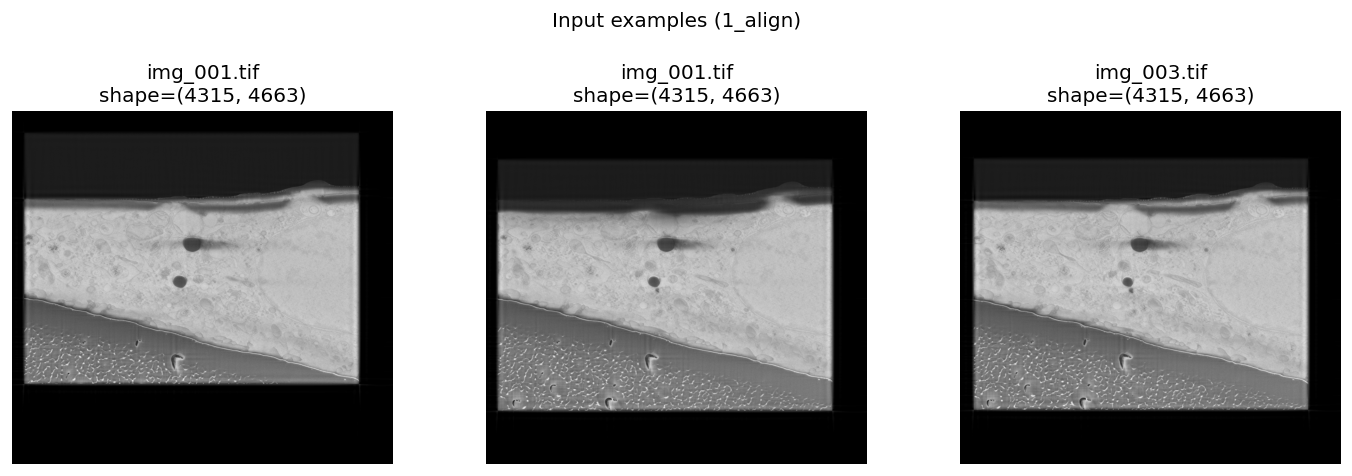

In [4]:
# Step 0: Visualize input
stage_header("Step 0 — Input (1_align)")
input_tifs = list_tifs(ALIGN_DIR)
print(f"Found {len(input_tifs)} tif(s) under {ALIGN_DIR}")
show_examples(input_tifs, "Input examples (1_align)")

# Tip: if this prints 0, add a few *.tif images under 1_align/part*/



Step 1 — Padding (pad_image.py)
[skip] padding outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/2_pad
Found 6 padded tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/2_pad


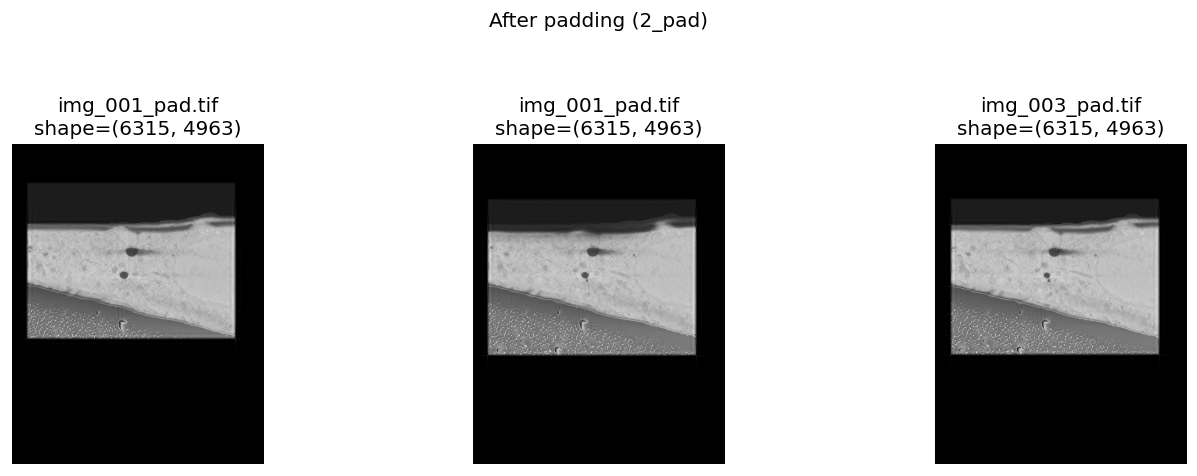

In [5]:
# Step 1: pad_image.py
stage_header("Step 1 — Padding (pad_image.py)")

pad_done = PAD_DIR.exists() and bool(list_tifs(PAD_DIR))
if FORCE_RERUN or not pad_done:
    cmd = [
        sys.executable,
        str(SCRIPTS_ROOT / "pad_image.py"),
        "--input",
        str(ALIGN_DIR),
        "--output_dir",
        str(PAD_DIR),
        "--mode",
        PAD_MODE,
        "--target_width",
        str(PAD_TARGET_WIDTH),
        "--target_height",
        str(PAD_TARGET_HEIGHT),
        "--pad_left",
        str(PAD_LEFT),
        "--pad_right",
        str(PAD_RIGHT),
        "--pad_top",
        str(PAD_TOP),
        "--pad_bottom",
        str(PAD_BOTTOM),
        "--lzw-compression",
        "True",
    ]
    run_cmd(cmd)
else:
    print(f"[skip] padding outputs already exist: {PAD_DIR}")

pad_tifs = list_tifs(PAD_DIR)
print(f"Found {len(pad_tifs)} padded tif(s) under {PAD_DIR}")
show_examples(pad_tifs, "After padding (2_pad)")



Step 2 — Drift correction (drift_correction.py)
[skip] drift outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/3_drift
Found 6 drift-corrected tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/3_drift


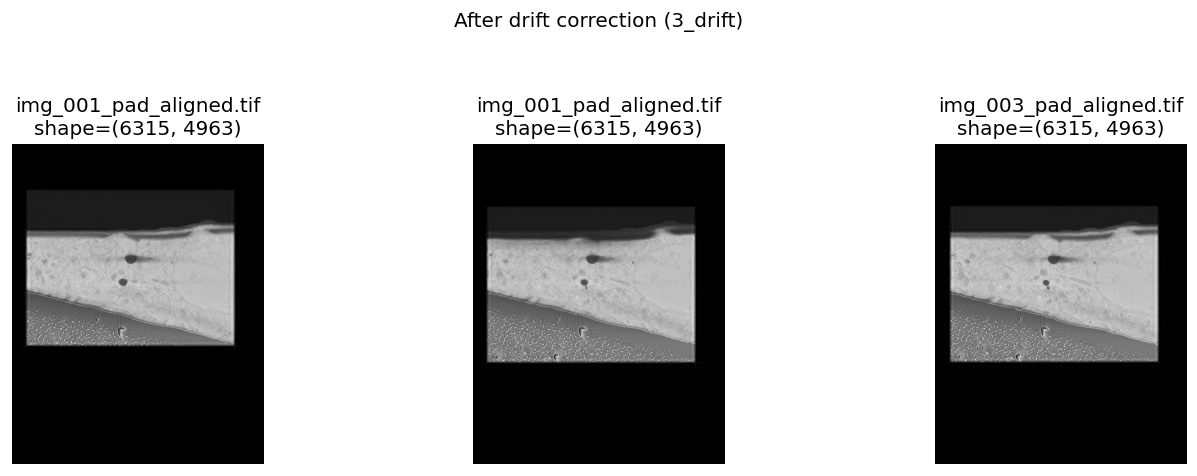

In [6]:
# Step 2: drift_correction.py (wraps drift_part.py)
stage_header("Step 2 — Drift correction (drift_correction.py)")

drift_done = DRIFT_DIR.exists() and bool(list_tifs(DRIFT_DIR))
if FORCE_RERUN or not drift_done:
    cmd = [
        sys.executable,
        str(SCRIPTS_ROOT / "drift_correction.py"),
        "--input-dir",
        str(PAD_DIR),
        "--output-dir",
        str(DRIFT_DIR),
        "--pattern",
        "*.tif",
        "--bit-depth",
        "8",
        "--lzw-compression",
        "True",
        "--verbose",
        "True",
        "--threshold",
        "50.0",
        "--drift-gap",
        "True",
    ]
    run_cmd(cmd)
else:
    print(f"[skip] drift outputs already exist: {DRIFT_DIR}")

drift_tifs = list_tifs(DRIFT_DIR)
print(f"Found {len(drift_tifs)} drift-corrected tif(s) under {DRIFT_DIR}")
show_examples(drift_tifs, "After drift correction (3_drift)")



Step 3 — Merge / re-index slices (merge_stack.py)
[skip] merge outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/4_merge
Found 6 merged/re-indexed tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/4_merge


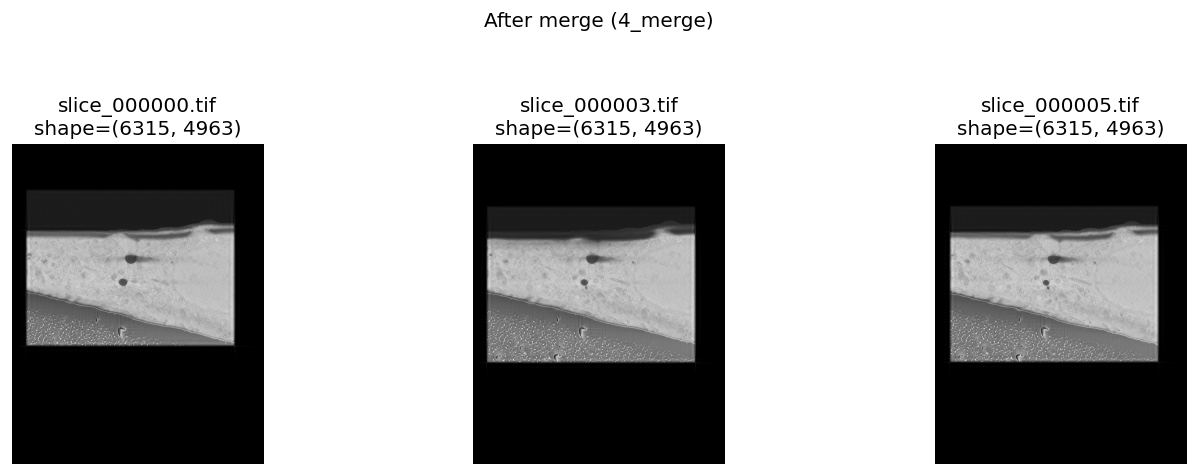

In [7]:
# Step 3: merge_stack.py
stage_header("Step 3 — Merge / re-index slices (merge_stack.py)")

merge_done = MERGE_DIR.exists() and bool(list_tifs(MERGE_DIR))
if FORCE_RERUN or not merge_done:
    MERGE_DIR.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        str(SCRIPTS_ROOT / "merge_stack.py"),
        "--input-dir",
        str(DRIFT_DIR),
        "--output-dir",
        str(MERGE_DIR),
        "--bit-depth",
        "8",
        "--lzw-compression",
        "False",
        "--verbose",
        "True",
    ]
    run_cmd(cmd)
else:
    print(f"[skip] merge outputs already exist: {MERGE_DIR}")

merge_tifs = list_tifs(MERGE_DIR)
print(f"Found {len(merge_tifs)} merged/re-indexed tif(s) under {MERGE_DIR}")
show_examples(merge_tifs, "After merge (4_merge)")



Step 4 — Reconstruction (reconstruct_sem.py)
[skip] reconstruction outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/5_reconstruct
Found 6 reconstructed tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/5_reconstruct


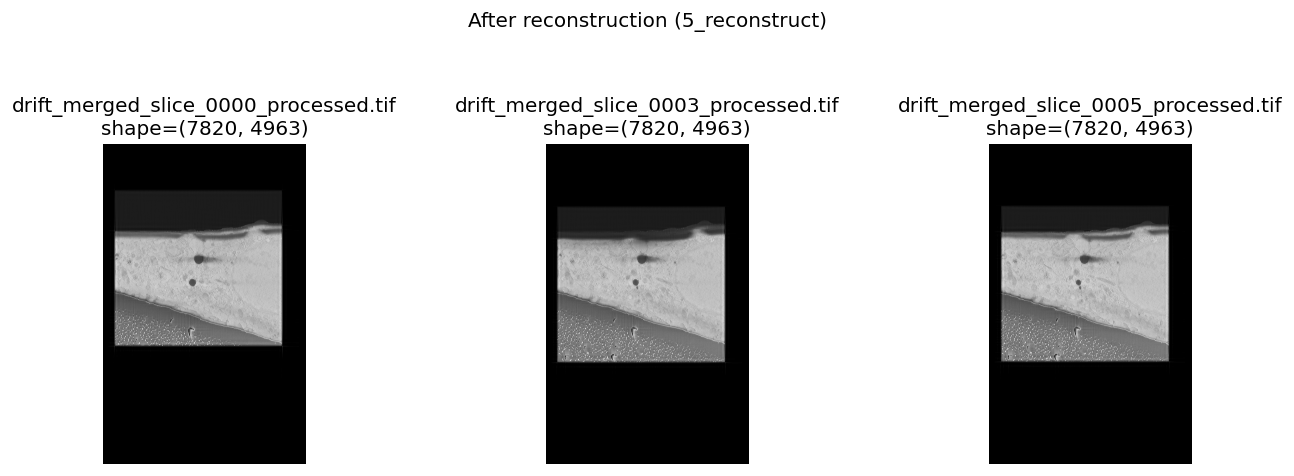

In [8]:
# Step 4: reconstruct_sem.py
stage_header("Step 4 — Reconstruction (reconstruct_sem.py)")

recon_done = RECON_DIR.exists() and bool(list_tifs(RECON_DIR))
if FORCE_RERUN or not recon_done:
    votex_str = f"({RECON_VOTEX_SIZE_NM[0]}, {RECON_VOTEX_SIZE_NM[1]}, {RECON_VOTEX_SIZE_NM[2]})"
    cmd = [
        sys.executable,
        str(SCRIPTS_ROOT / "reconstruct_sem.py"),
        "--input-file",
        str(MERGE_DIR),
        "--output-path",
        str(RECON_DIR),
        "--angle",
        str(RECON_ANGLE_DEG),
        "--interpolation",
        RECON_INTERP,
        "--bit-depth",
        "8",
        "--votex-size",
        votex_str,
        "--no-lzw-compression",
    ]
    run_cmd(cmd)
else:
    print(f"[skip] reconstruction outputs already exist: {RECON_DIR}")

recon_tifs = list_tifs(RECON_DIR)
print(f"Found {len(recon_tifs)} reconstructed tif(s) under {RECON_DIR}")
show_examples(recon_tifs, "After reconstruction (5_reconstruct)")



Step 5 — Flip (flip_sem.py)
[skip] flip outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/6_flip
Found 6 flipped tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/6_flip


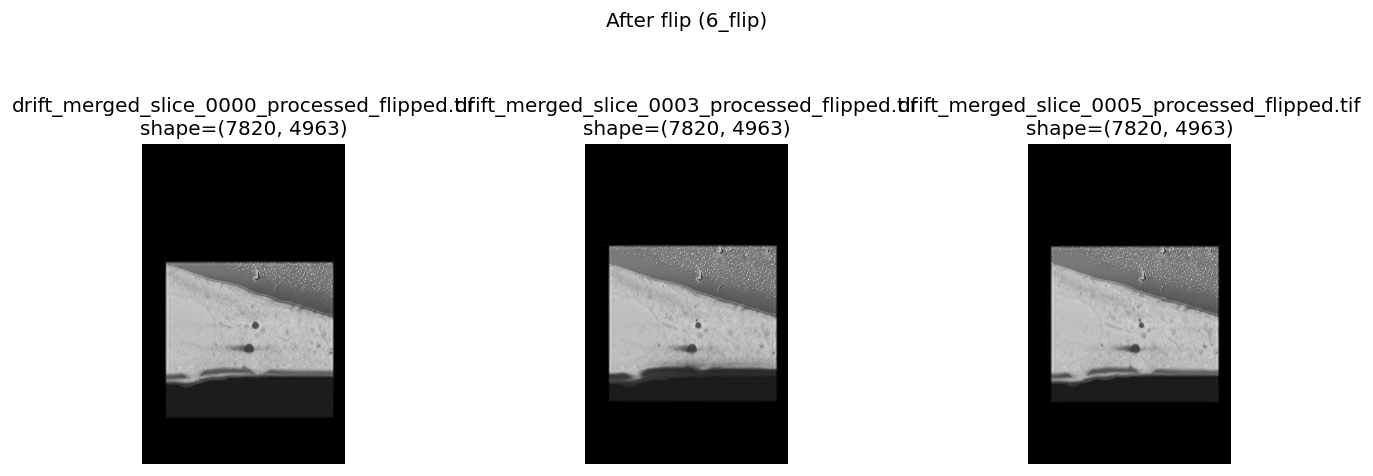

In [9]:
# Step 5: flip_sem.py
stage_header("Step 5 — Flip (flip_sem.py)")

flip_done = FLIP_DIR.exists() and bool(list_tifs(FLIP_DIR))
if FORCE_RERUN or not flip_done:
    cmd = [
        sys.executable,
        str(SCRIPTS_ROOT / "flip_sem.py"),
        "--input-dir",
        str(RECON_DIR),
        "--output-dir",
        str(FLIP_DIR),
        "--pattern",
        "*.tif",
        "--bit-depth",
        "8",
        "--no-lzw-compression",
    ]
    run_cmd(cmd)
else:
    print(f"[skip] flip outputs already exist: {FLIP_DIR}")

flip_tifs = list_tifs(FLIP_DIR)
print(f"Found {len(flip_tifs)} flipped tif(s) under {FLIP_DIR}")
show_examples(flip_tifs, "After flip (6_flip)")



Step 6 — Crop redundant background (delete_redundant_BG.py)
[skip] deleteBG outputs already exist: /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/7_deleteBG
Found 6 cropped tif(s) under /Volumes/T7/20251204_halfCell/CLIEM_code/Preprocess/src/toy_example/7_deleteBG


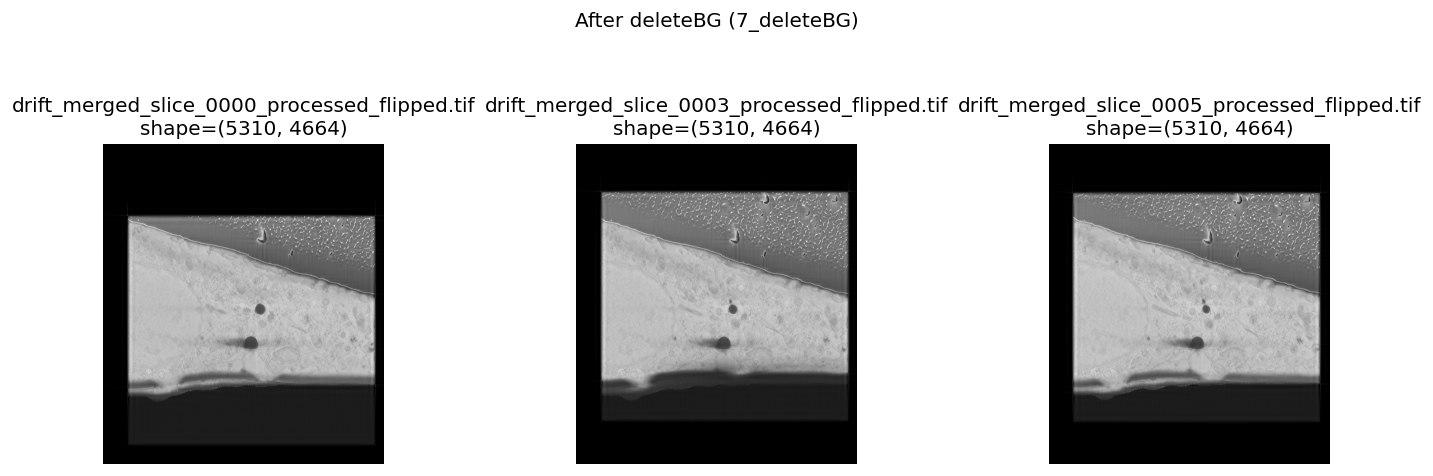

In [10]:
# Step 6: delete redundant background
stage_header("Step 6 — Crop redundant background (delete_redundant_BG.py)")

from delete_redundant_BG import delete_redundant_background

delete_done = DELETE_BG_DIR.exists() and bool(list_tifs(DELETE_BG_DIR))
if FORCE_RERUN or not delete_done:
    delete_redundant_background(
        stack_dir=FLIP_DIR,
        output_dir=DELETE_BG_DIR,
        pattern="*.tif",
        use_lzw=True,
    )
else:
    print(f"[skip] deleteBG outputs already exist: {DELETE_BG_DIR}")

delete_tifs = list_tifs(DELETE_BG_DIR)
print(f"Found {len(delete_tifs)} cropped tif(s) under {DELETE_BG_DIR}")
show_examples(delete_tifs, "After deleteBG (7_deleteBG)")


### Notes

- If you only want visualization (no re-running), set `FORCE_RERUN = False` and make sure the stage outputs exist.
- If you change any parameters, set `FORCE_RERUN = True` to regenerate outputs.
- If `Step 0` shows **0 images**, add a few `*.tif` files under `1_align/part*/`.
- `merge_stack.py` writes **individual 2D slices** into `4_merge/` (e.g. `slice_000000.tif`), and `reconstruct_sem.py` can read a directory of such slices.
